# 02 — Full pairwise sleep-history exploration (total sleep + deep sleep, days 1-7)

Extends notebook 01's lag analysis in three ways:

1. **Single-day lags** — the sleep on exactly night N before, alone (not averaged
   with any other night). Notebook 01 only ever averaged *cumulatively* from
   night 1 up to night N; this isolates whether one specific night (e.g. night 2)
   carries a unique signal on its own.
2. **Skip-day pairwise combinations** — the average of any two specific nights
   from the trailing 7, including non-adjacent pairs (e.g. night 2 + night 4,
   skipping night 3). Tests whether particular *combinations* of nights matter
   in a way a simple cumulative average would wash out.
3. **Deep sleep hours** as its own metric, run through the same three
   treatments (single-day, cumulative 1-7 day average, pairwise) as
   `total_sleep_hours` — to see whether it's total sleep or specifically deep
   sleep driving any HRV/RHR relationship.
4. Lookback extended from 5 days to **7 days** throughout.

This produces 74 sleep variables x 2 outcomes = 148 variable pairs — too many
for one scatter grid, so plots are split into 7 logical figures (saved as
separate PNGs) and the full r/p table is sorted by |r| so the strongest
relationships surface first regardless of which category they came from.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import combinations

df = pd.read_csv("../data/daily.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"{len(df)} days, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

270 days, 2025-12-19 to 2026-09-14


,cycle_id,date,day_strain,day_avg_hr,day_max_hr,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,...,hours_rem_sleep,disturbance_count,hours_sleep_debt,hours_needed_baseline,num_workouts,sports,distance_meter_total,zone1_3_minutes,zone4_5_minutes,total_kcal_burned
0,1209987462,2025-12-19,5.891211,64,147,79.0,51.0,81.096750,94.10526,34.542835,...,1.330972,17.0,0.000000,7.911577,0,NaN,0.0,0.000000,0.000000,2021.697419
1,1210683893,2025-12-20,13.061315,74,155,83.0,49.0,83.903230,95.50000,34.208275,...,0.700281,8.0,0.560294,7.911453,1,spin,0.0,42.633667,0.000000,2032.031071
2,1213120705,2025-12-21,11.462260,72,163,82.0,53.0,82.978980,95.95000,34.529667,...,1.767831,17.0,1.164866,7.911330,1,walking,0.0,23.950167,0.266667,1990.981358
3,1214335689,2025-12-22,4.732262,67,119,4.0,61.0,46.241234,89.00000,34.420666,...,0.268367,2.0,1.413727,7.911207,0,NaN,0.0,0.000000,0.000000,1234.770148
4,1215444003,2025-12-22,17.598125,76,194,40.0,49.0,68.771255,94.56250,33.957000,...,1.317000,18.0,2.130000,7.911207,0,NaN,0.0,0.000000,0.000000,2995.576482


## Build the sleep variables

- `total_sleep_hours` — light + deep + REM (same definition as notebook 01).
- `deep_sleep_hours` — deep/slow-wave sleep only.
- For **each** of those two metrics, build three families of lag variables
  over nights 1 through 7 before the current one:
  - `{metric}_Nd_before` — the single night exactly N nights back, alone
    (`shift(N)`, no averaging).
  - `{metric}_prior_Nd_avg` — cumulative rolling mean of the trailing N
    nights, shifted so it excludes the current night (same construction as
    notebook 01, just extended to N=6 and N=7).
  - `{metric}_avg_id_jd_before` — the average of just nights i and j (for
    every i < j in 1..7), built directly from the single-day columns above.
    This is the "skip-day" family: e.g. `avg_2d_4d_before` skips night 3
    entirely.
- `sleep_consistency_pct` and `sleep_efficiency_pct` are carried over as
  same-night variables, same as notebook 01.

In [2]:
df["total_sleep_hours"] = df["hours_light_sleep"] + df["hours_deep_sleep"] + df["hours_rem_sleep"]
df["deep_sleep_hours"] = df["hours_deep_sleep"]

sleep_metrics = ["total_sleep_hours", "deep_sleep_hours"]
max_lag = 7
lag_vars = {}  # metric -> {"single": [...], "cumulative": [...], "pairwise": [...]}

for metric in sleep_metrics:
    single = []
    for n in range(1, max_lag + 1):
        col = f"{metric}_{n}d_before"
        df[col] = df[metric].shift(n)
        single.append(col)

    cumulative = []
    for n in range(1, max_lag + 1):
        col = f"{metric}_prior_{n}d_avg"
        df[col] = df[metric].shift(1).rolling(window=n, min_periods=n).mean()
        cumulative.append(col)

    pairwise = []
    for i, j in combinations(range(1, max_lag + 1), 2):
        col = f"{metric}_avg_{i}d_{j}d_before"
        df[col] = df[[f"{metric}_{i}d_before", f"{metric}_{j}d_before"]].mean(axis=1)
        pairwise.append(col)

    lag_vars[metric] = {"single": single, "cumulative": cumulative, "pairwise": pairwise}

same_night_vars = ["total_sleep_hours", "sleep_consistency_pct", "sleep_efficiency_pct", "deep_sleep_hours"]
outcome_vars = ["hrv_rmssd_milli", "resting_heart_rate"]

sleep_vars = same_night_vars.copy()
for metric in sleep_metrics:
    sleep_vars += lag_vars[metric]["single"] + lag_vars[metric]["cumulative"] + lag_vars[metric]["pairwise"]

print(f"{len(sleep_vars)} sleep variables x {len(outcome_vars)} outcomes = {len(sleep_vars) * len(outcome_vars)} pairs")

74 sleep variables x 2 outcomes = 148 pairs


## Correlation + significance for every pair, sorted by strength

Same Pearson r / p-value approach as notebook 01, computed for all 148 pairs
and sorted by |r| descending so the strongest relationships — from *any*
category — are at the top rather than buried in variable-name order.

In [3]:
results = []
for sv in sleep_vars:
    for ov in outcome_vars:
        pair = df[[sv, ov]].dropna()
        r, p = pearsonr(pair[sv], pair[ov])
        results.append({"sleep_var": sv, "outcome": ov, "n": len(pair), "r": round(r, 3), "p_value": round(p, 4)})

results_df = pd.DataFrame(results)
results_df["abs_r"] = results_df["r"].abs()
results_df = results_df.sort_values("abs_r", ascending=False).drop(columns="abs_r").reset_index(drop=True)
results_df

,sleep_var,outcome,n,r,p_value
0,deep_sleep_hours,resting_heart_rate,270,-0.194,0.0013
1,total_sleep_hours_prior_6d_avg,hrv_rmssd_milli,264,-0.190,0.0020
2,total_sleep_hours_prior_5d_avg,hrv_rmssd_milli,265,-0.185,0.0025
3,deep_sleep_hours_prior_7d_avg,hrv_rmssd_milli,263,-0.184,0.0028
4,total_sleep_hours_prior_7d_avg,hrv_rmssd_milli,263,-0.183,0.0029
...,...,...,...,...,...
143,total_sleep_hours_prior_5d_avg,resting_heart_rate,265,0.005,0.9311
144,total_sleep_hours_avg_3d_6d_before,resting_heart_rate,267,0.005,0.9375
145,total_sleep_hours_3d_before,resting_heart_rate,267,0.003,0.9657
146,total_sleep_hours_avg_2d_3d_before,resting_heart_rate,268,0.003,0.9634


## Top 20 strongest relationships

In [4]:
results_df.head(20)

,sleep_var,outcome,n,r,p_value
0,deep_sleep_hours,resting_heart_rate,270,-0.194,0.0013
1,total_sleep_hours_prior_6d_avg,hrv_rmssd_milli,264,-0.190,0.0020
2,total_sleep_hours_prior_5d_avg,hrv_rmssd_milli,265,-0.185,0.0025
3,deep_sleep_hours_prior_7d_avg,hrv_rmssd_milli,263,-0.184,0.0028
4,total_sleep_hours_prior_7d_avg,hrv_rmssd_milli,263,-0.183,0.0029
5,deep_sleep_hours_prior_5d_avg,hrv_rmssd_milli,265,-0.176,0.0041
6,deep_sleep_hours_prior_6d_avg,hrv_rmssd_milli,264,-0.169,0.0058
7,total_sleep_hours_avg_4d_5d_before,hrv_rmssd_milli,266,-0.165,0.0071
8,total_sleep_hours_avg_1d_5d_before,hrv_rmssd_milli,269,-0.162,0.0079
9,total_sleep_hours_avg_1d_4d_before,hrv_rmssd_milli,269,-0.160,0.0086


## Scatter plots

Split into 7 figures (same-night vars, then single-day / cumulative / pairwise
for each of the two sleep metrics) rather than one 74-row grid. Each is saved
to `../output/` as its own PNG.

In [5]:
def plot_group(vars_list, name):
    fig, axes = plt.subplots(len(vars_list), len(outcome_vars), figsize=(10, 3.2 * len(vars_list)), squeeze=False)
    for i, sv in enumerate(vars_list):
        for j, ov in enumerate(outcome_vars):
            ax = axes[i, j]
            pair = df[[sv, ov]].dropna()
            ax.scatter(pair[sv], pair[ov], alpha=0.4, s=15)
            if len(pair) > 1:
                m, b = np.polyfit(pair[sv], pair[ov], 1)
                xs = np.linspace(pair[sv].min(), pair[sv].max(), 50)
                ax.plot(xs, m * xs + b, color="red", linewidth=1)
                r, p = pearsonr(pair[sv], pair[ov])
                ax.text(
                    0.03, 0.96, f"r={r:.3f}\np={p:.4f}\nn={len(pair)}",
                    transform=ax.transAxes, va="top", ha="left", fontsize=8,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"),
                )
            ax.set_xlabel(sv, fontsize=8)
            ax.set_ylabel(ov, fontsize=8)
    plt.tight_layout()
    out_path = f"../output/02_{name}_scatter.png"
    plt.savefig(out_path, dpi=120)
    plt.show()
    print(f"saved {out_path}")

### Same-night variables

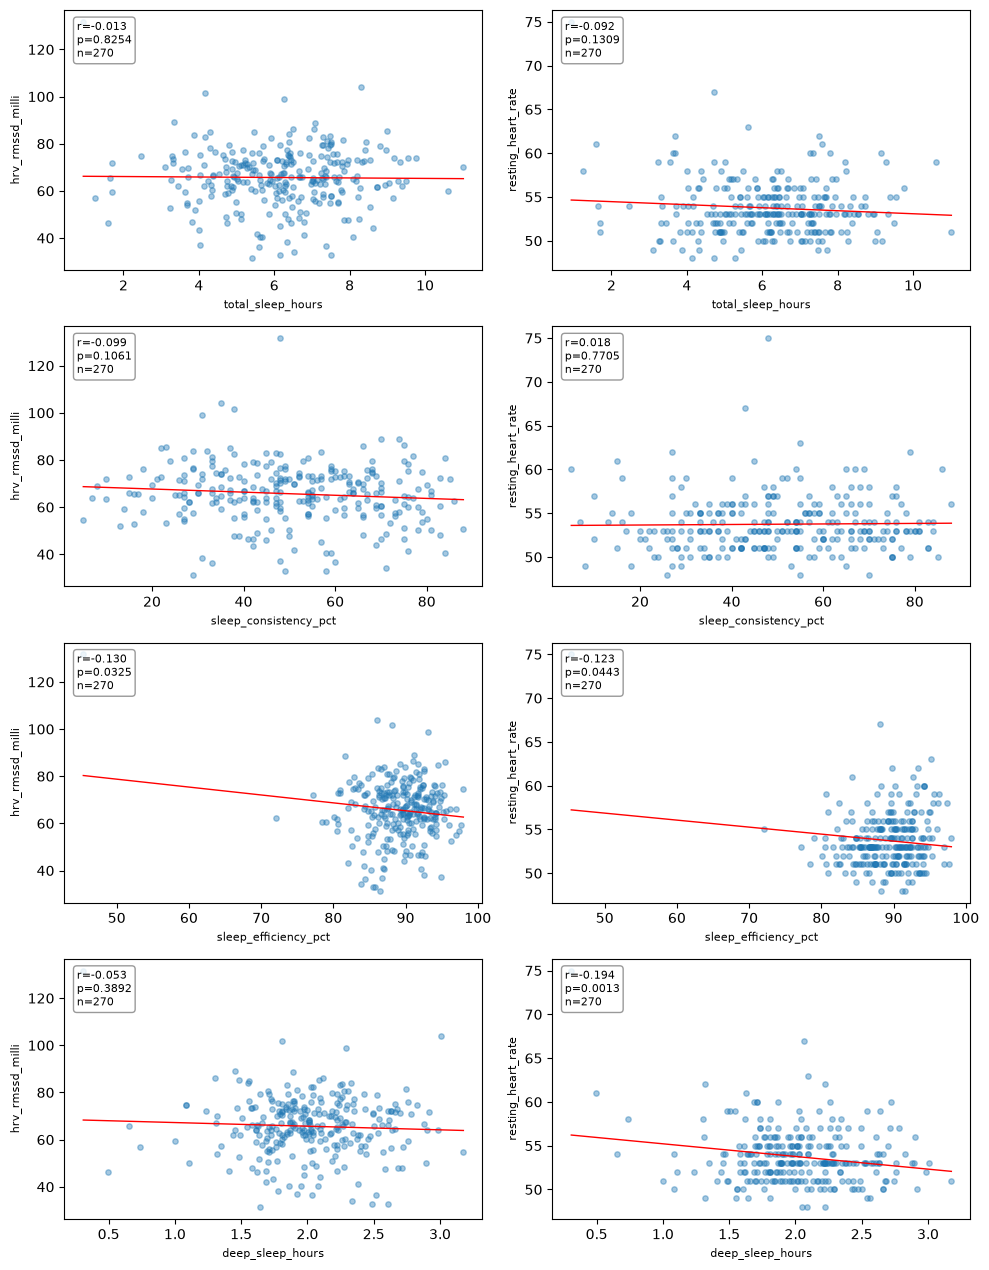

saved ../output/02_same_night_scatter.png


In [6]:
plot_group(same_night_vars, "same_night")

### total_sleep_hours — single-day lags (night N alone, N=1-7)

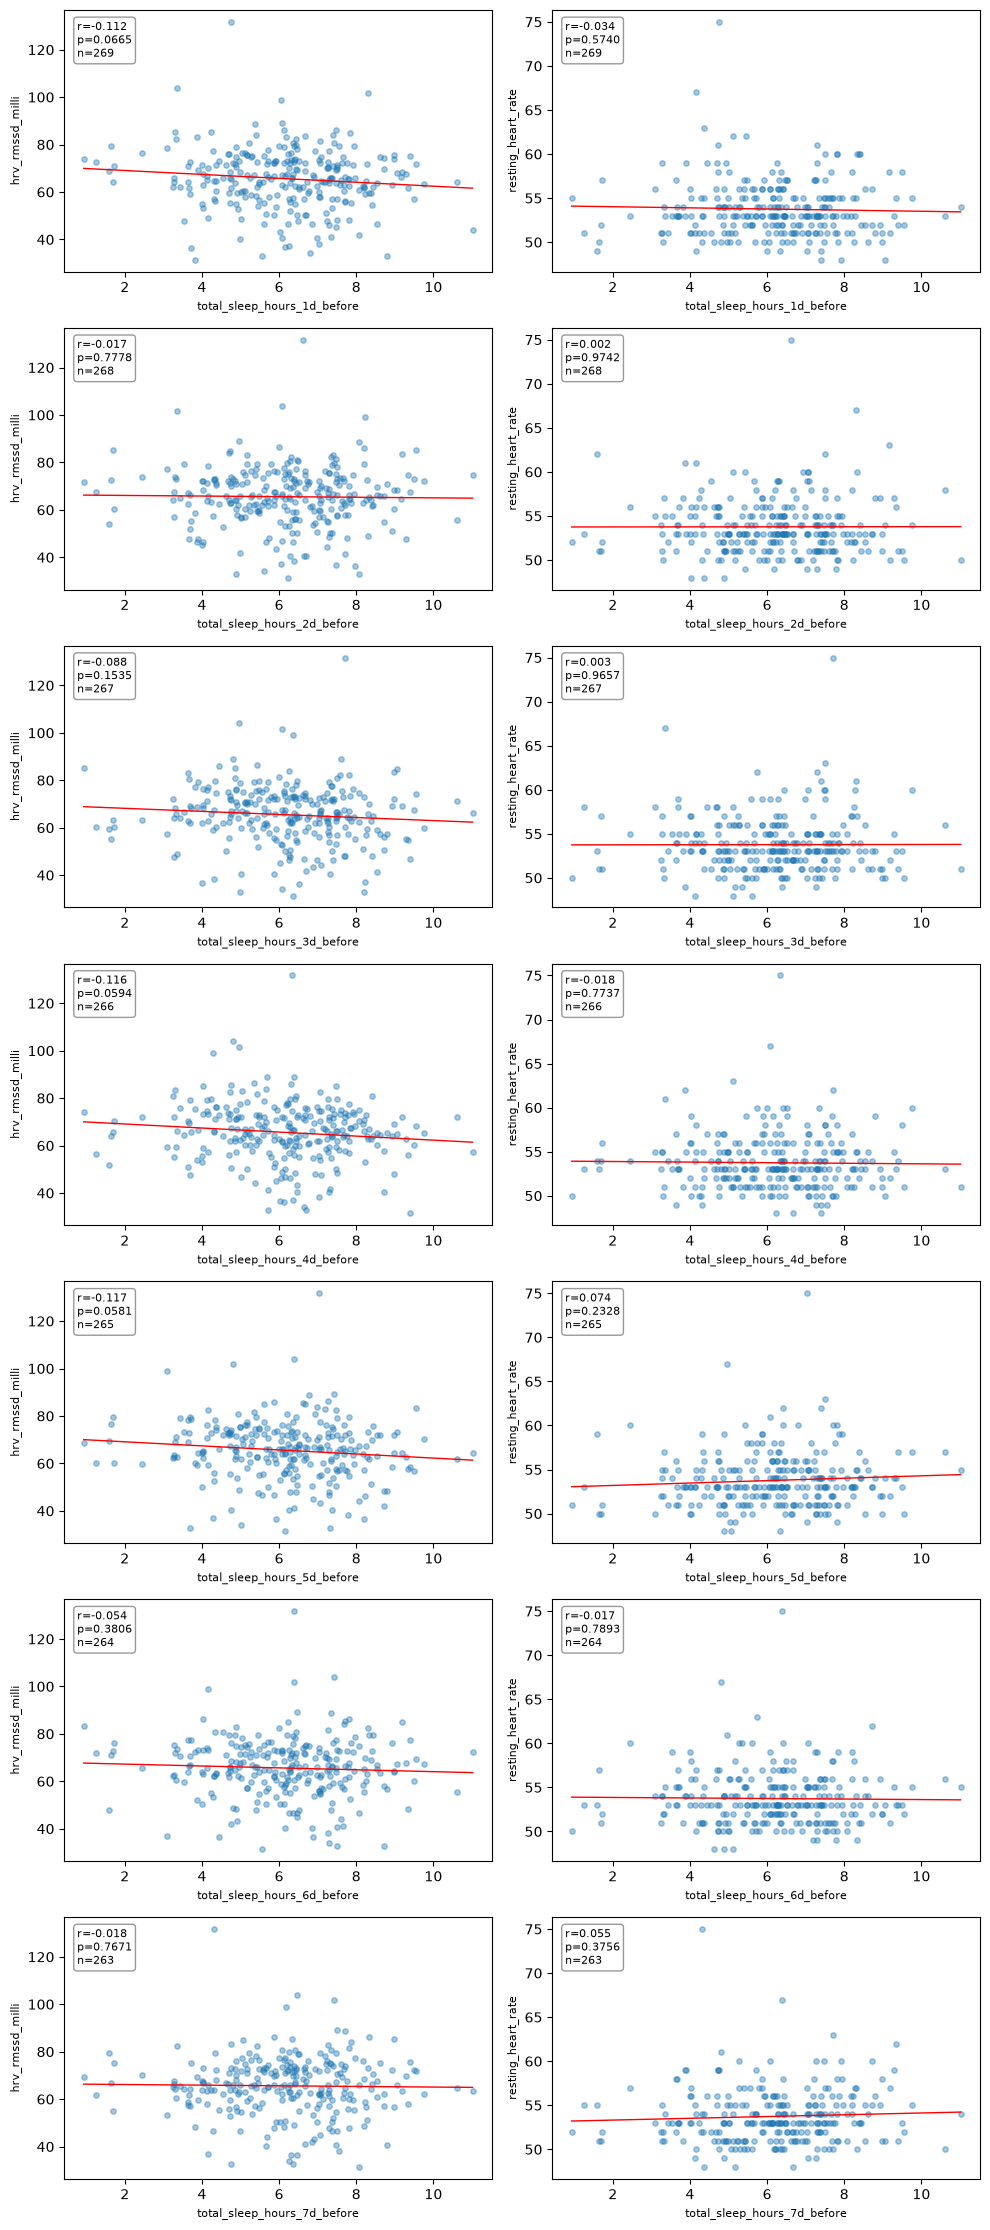

saved ../output/02_total_sleep_single_day_lags_scatter.png


In [7]:
plot_group(lag_vars["total_sleep_hours"]["single"], "total_sleep_single_day_lags")

### total_sleep_hours — cumulative 1-7 day averages

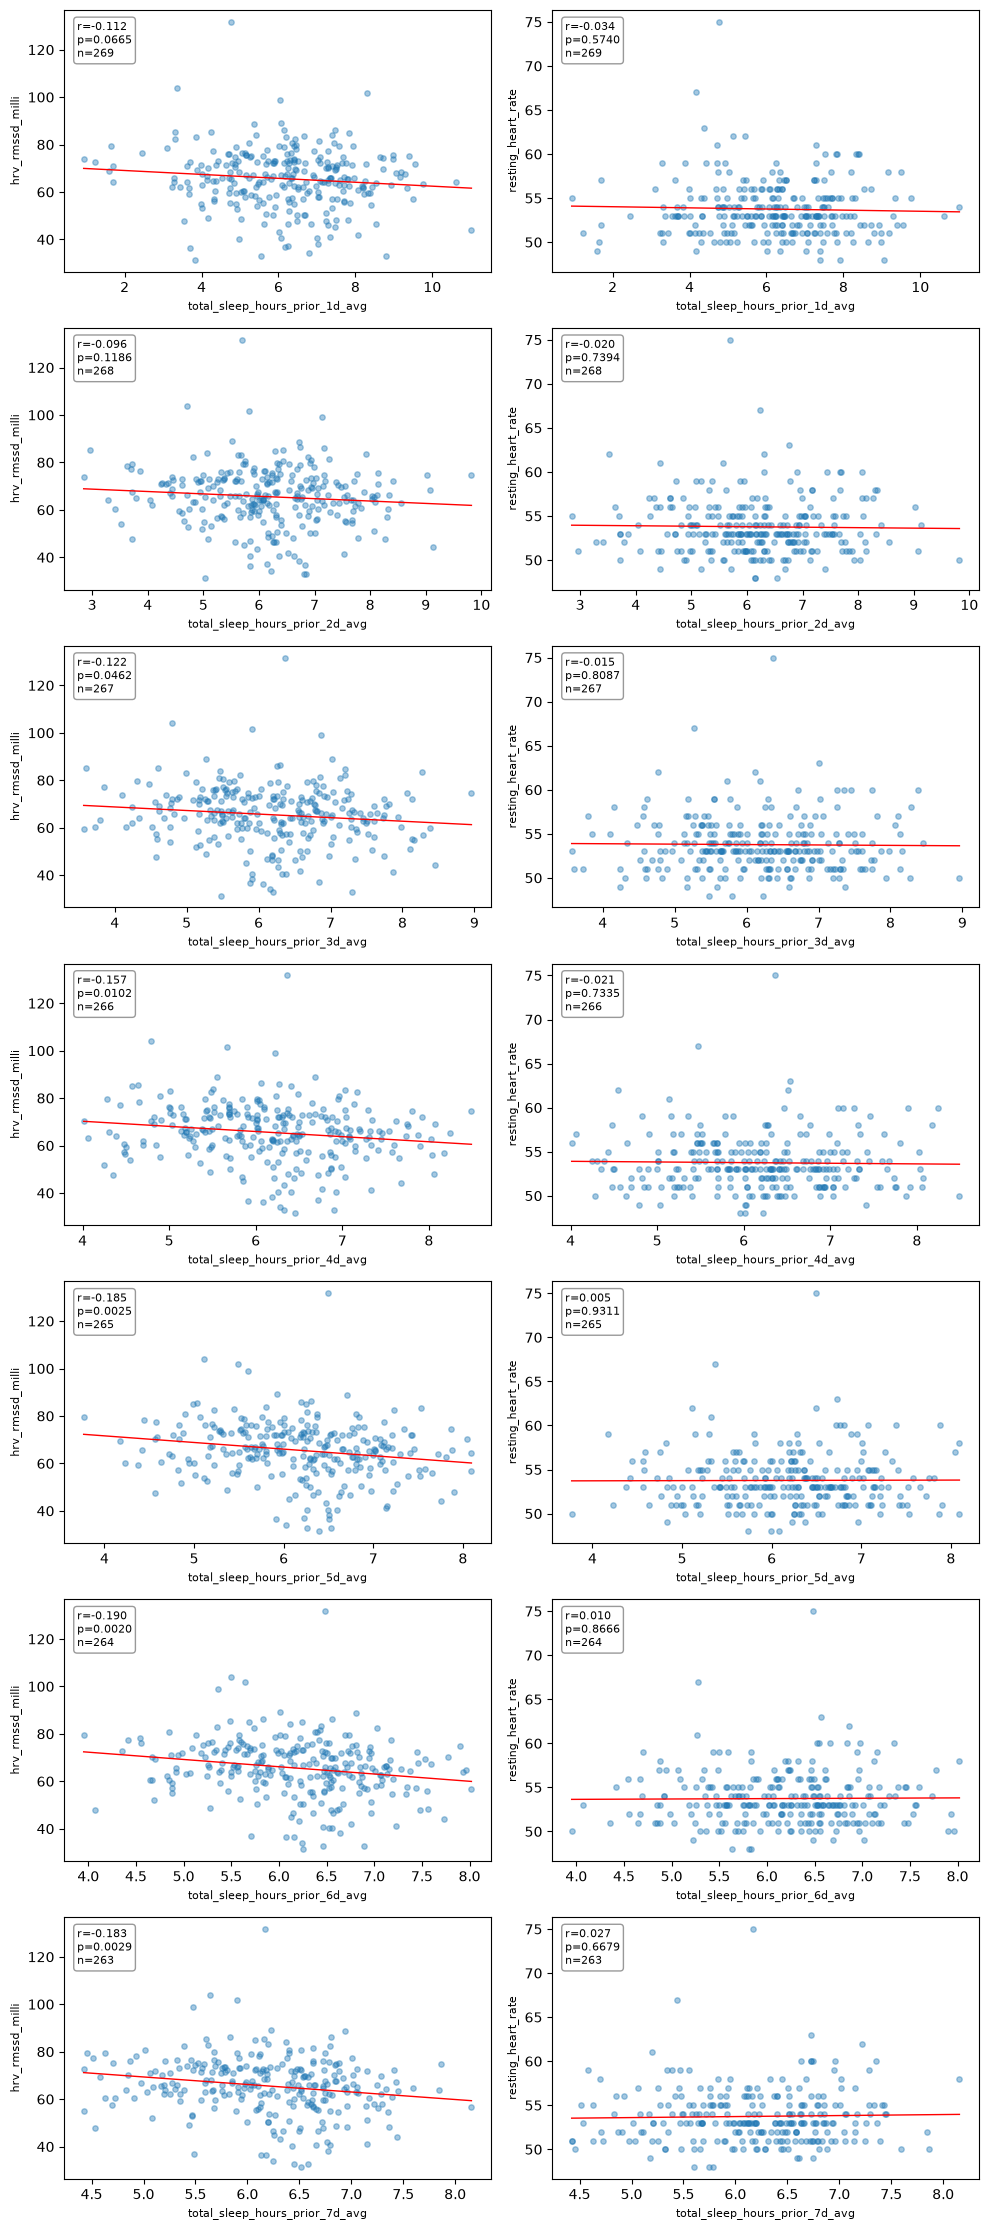

saved ../output/02_total_sleep_cumulative_avgs_scatter.png


In [8]:
plot_group(lag_vars["total_sleep_hours"]["cumulative"], "total_sleep_cumulative_avgs")

### total_sleep_hours — skip-day pairwise combinations (21 pairs from nights 1-7)

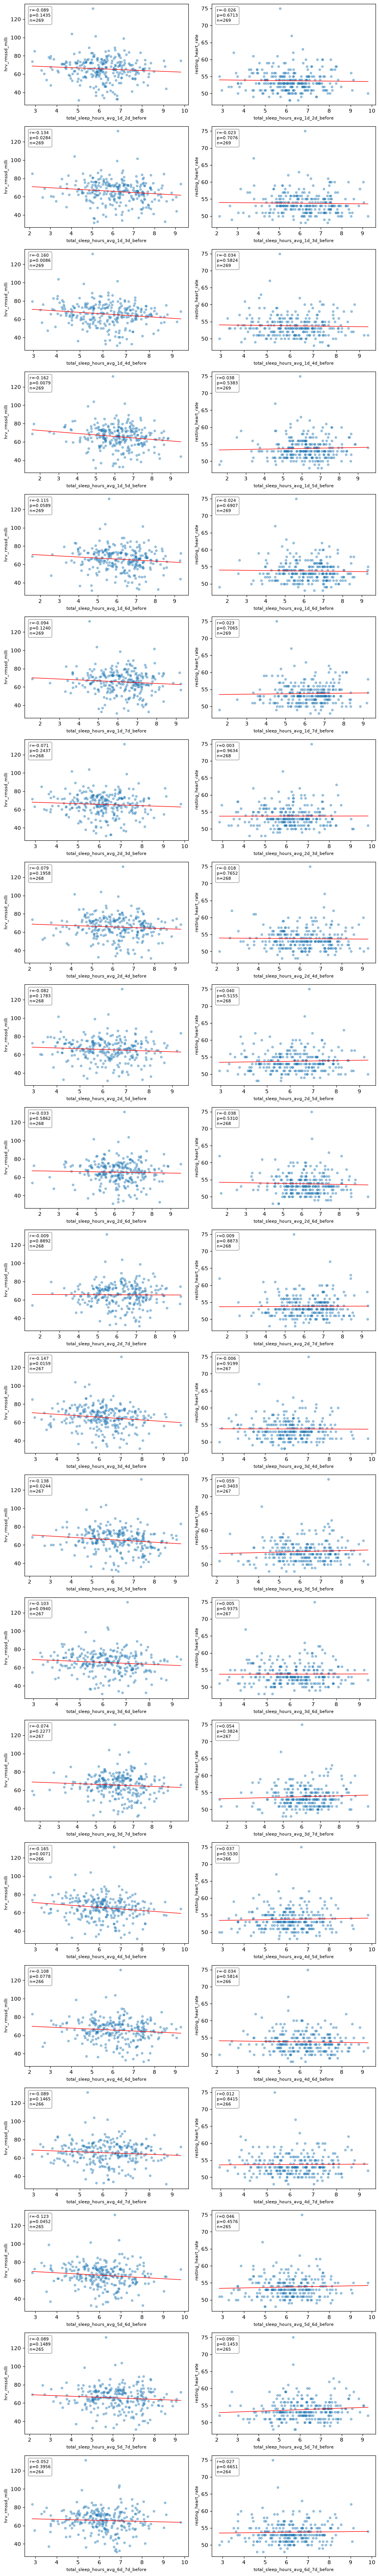

saved ../output/02_total_sleep_pairwise_combos_scatter.png


In [9]:
plot_group(lag_vars["total_sleep_hours"]["pairwise"], "total_sleep_pairwise_combos")

### deep_sleep_hours — single-day lags (night N alone, N=1-7)

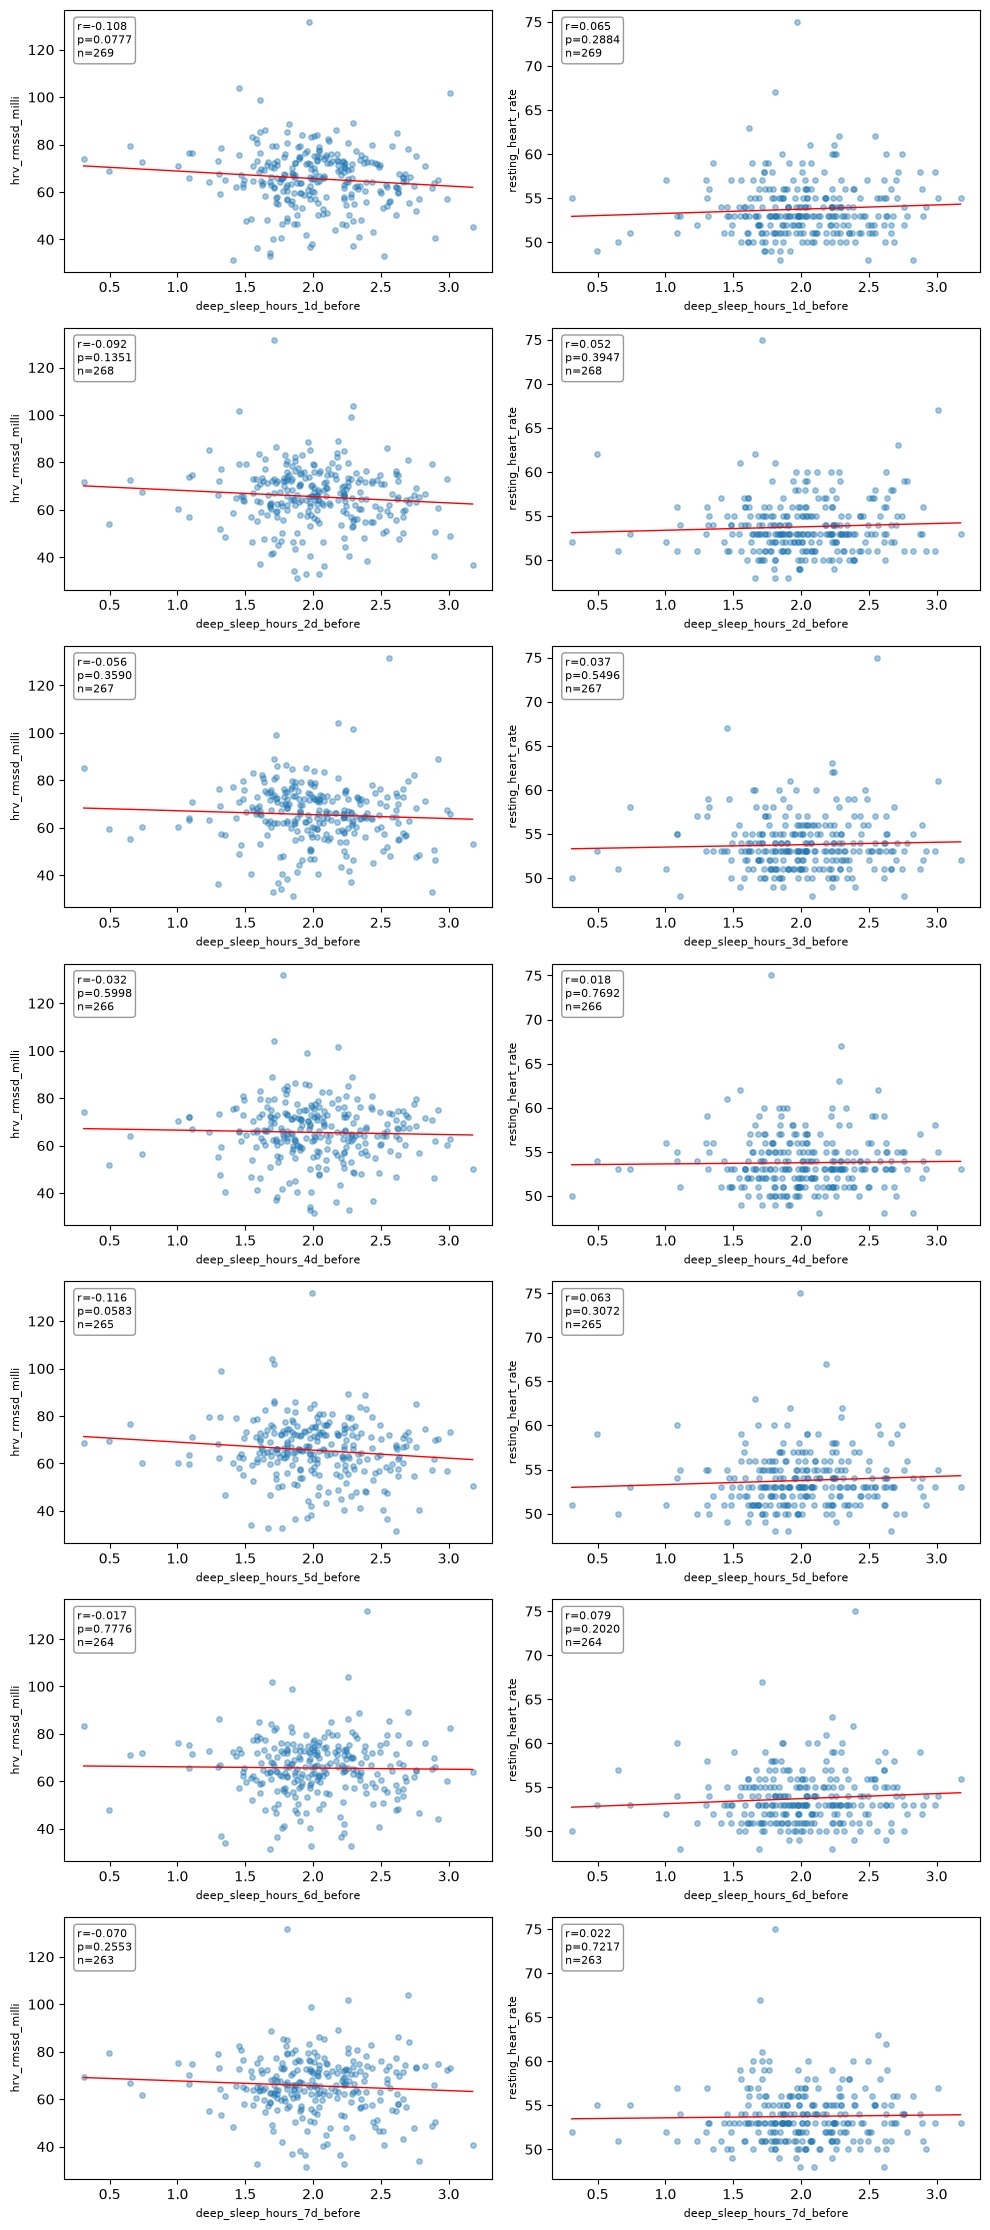

saved ../output/02_deep_sleep_single_day_lags_scatter.png


In [10]:
plot_group(lag_vars["deep_sleep_hours"]["single"], "deep_sleep_single_day_lags")

### deep_sleep_hours — cumulative 1-7 day averages

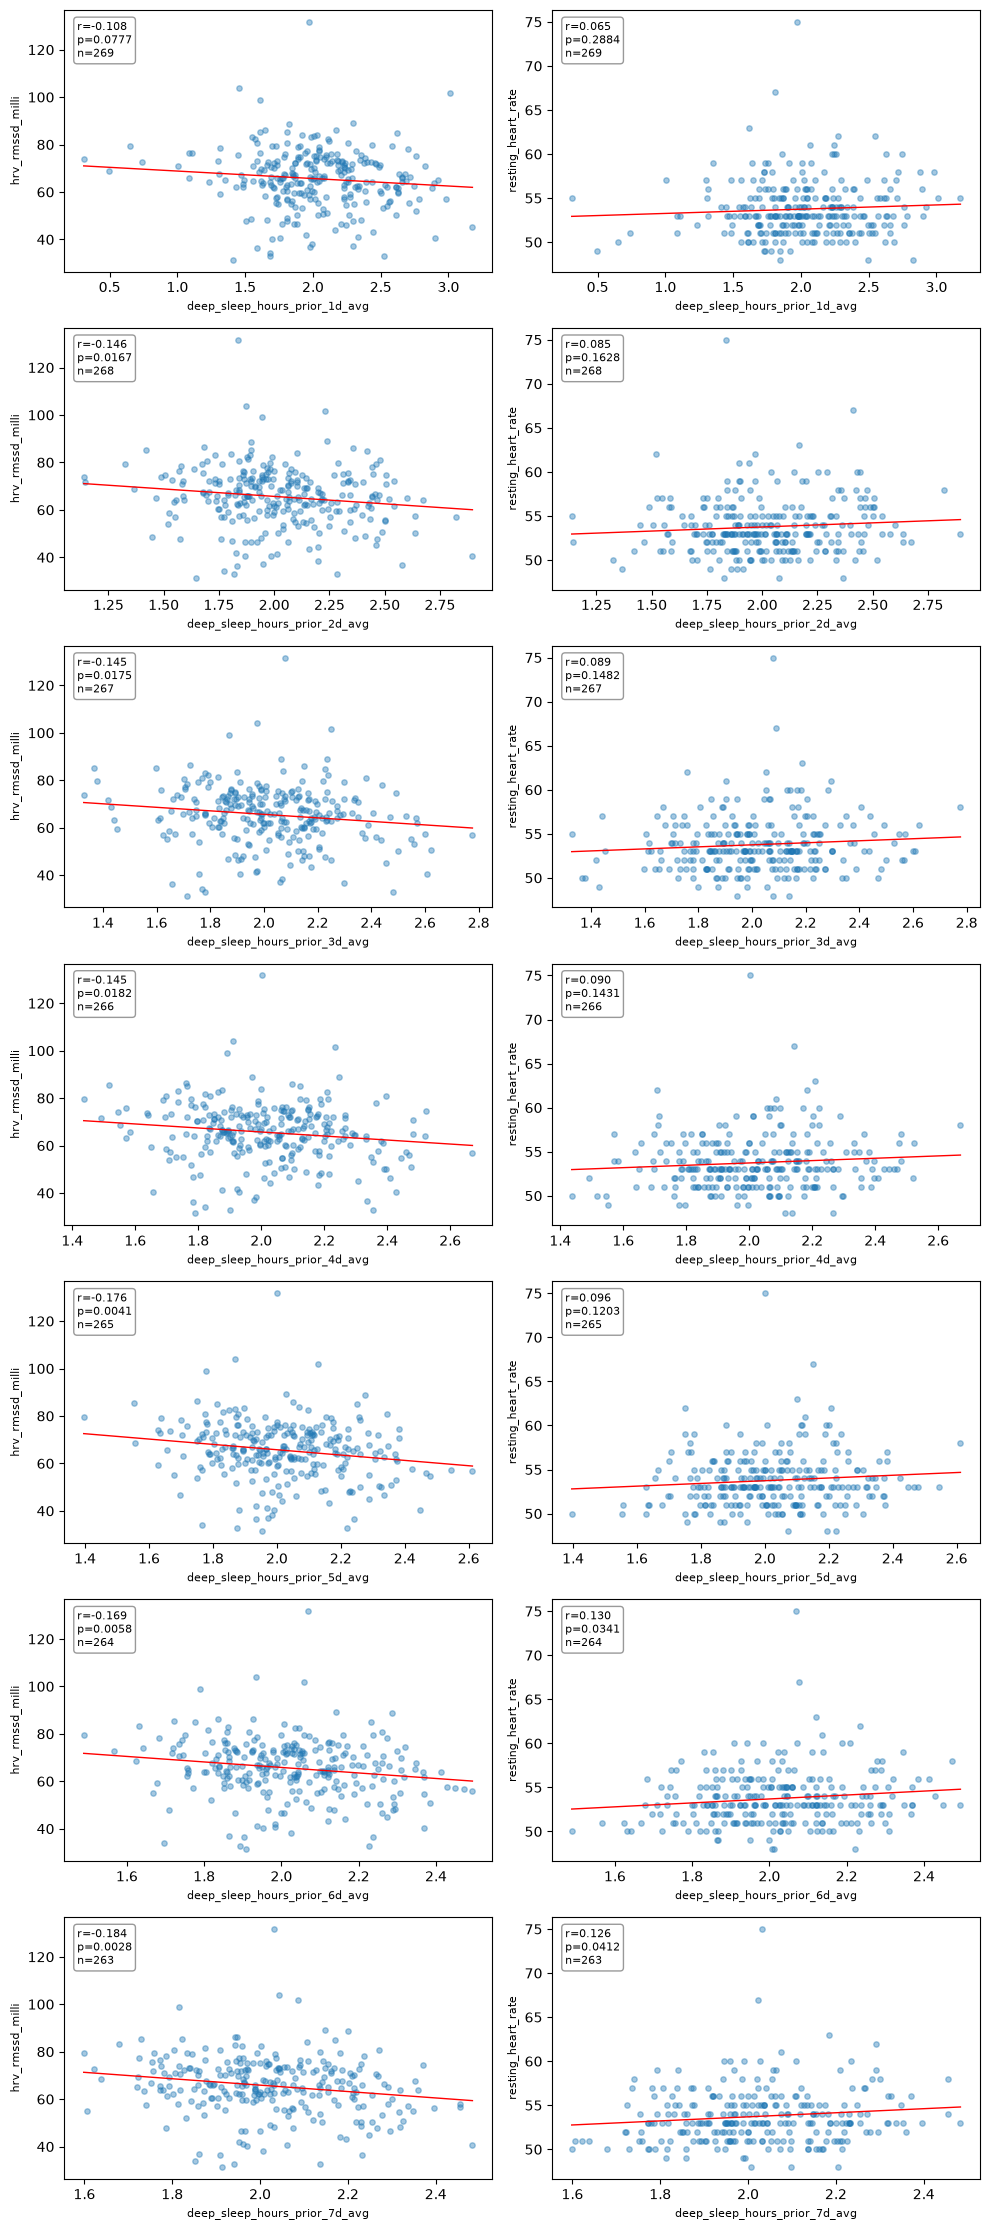

saved ../output/02_deep_sleep_cumulative_avgs_scatter.png


In [11]:
plot_group(lag_vars["deep_sleep_hours"]["cumulative"], "deep_sleep_cumulative_avgs")

### deep_sleep_hours — skip-day pairwise combinations (21 pairs from nights 1-7)

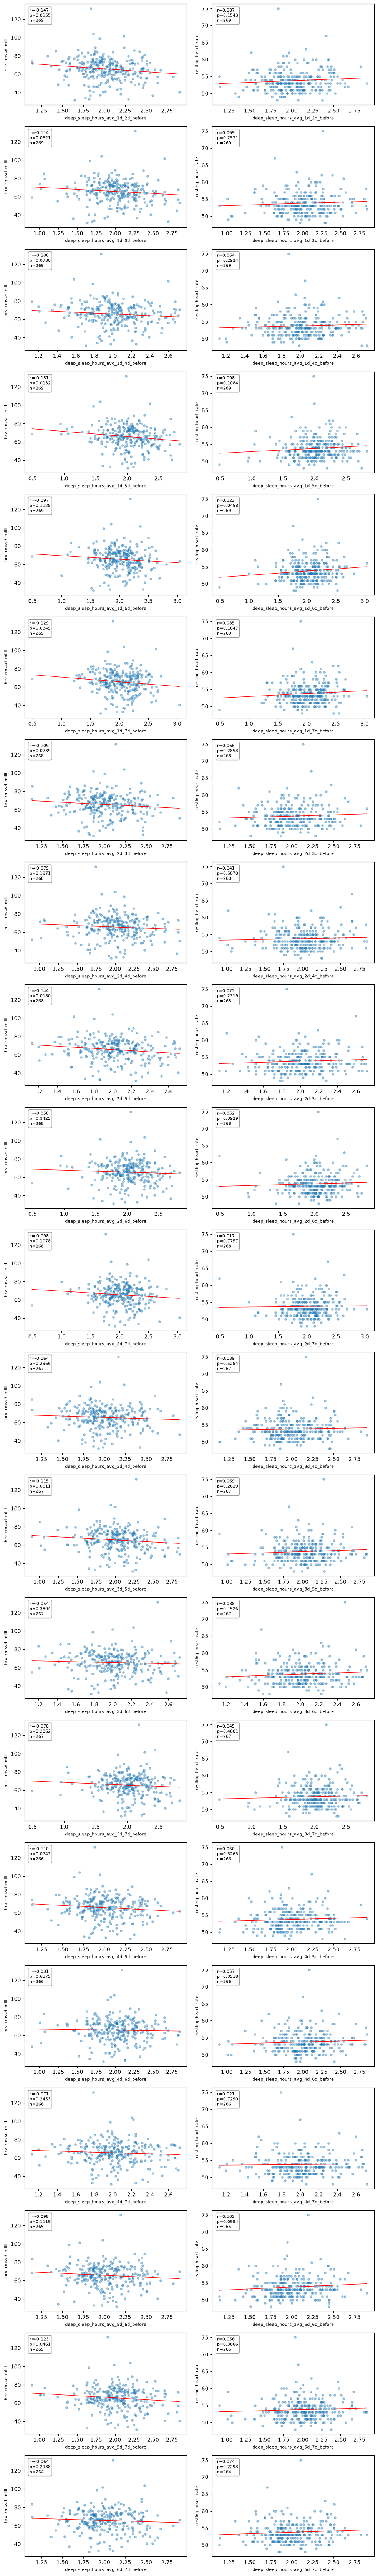

saved ../output/02_deep_sleep_pairwise_combos_scatter.png


In [12]:
plot_group(lag_vars["deep_sleep_hours"]["pairwise"], "deep_sleep_pairwise_combos")

## Findings

Ran on 270 days (2025-12-19 to 2026-09-14), 74 sleep variables x 2 outcomes = 148 pairs.

- **Isolated single-day lags (a night exactly N ago, alone, no averaging with
  any other night) show essentially no signal anywhere.** Of the 28
  single-day-lag pairs (7 days x 2 metrics = 14 variables x 2 outcomes = 28
  pairs), **zero** are significant at p<0.05 — the strongest is
  `total_sleep_hours_5d_before` vs HRV at only r=-0.117, p=0.058, not quite
  significant. This directly tests (and does not support) the
  day-2-specifically hypothesis: `total_sleep_hours_2d_before` vs HRV comes
  back at r=-0.017, p=0.78 - indistinguishable from noise. No single
  isolated night, at any lag, carries a unique signal on its own.
- **Cumulative averages are the strongest category**: 13 of 28
  cumulative-average pairs (46%) are significant, concentrated at the long
  end - `total_sleep_hours_prior_6d_avg` vs HRV is the single strongest
  relationship in the *entire lag table* (r=-0.190, p=0.0020), just ahead of
  prior_5d (r=-0.185) and prior_7d (r=-0.183). Same pattern holds for
  `deep_sleep_hours_prior_Nd_avg`. This replicates and extends notebook 01's
  finding: it's accumulated debt, not any specific night, that predicts
  next-day HRV, and 5-7 days is roughly the effective window (it plateaus
  rather than keeps climbing at 7).
- **Skip-day pairwise combinations mostly track the same story**: 13 of 84
  pairwise pairs are significant, and every one of the significant ones
  involves a wide gap (e.g. `avg_4d_5d_before`, `avg_1d_5d_before`,
  `avg_3d_4d_before`) rather than adjacent close-together days - consistent
  with "the more days of history you fold in, the stronger it gets" rather
  than any specific pair of days being magic. No non-adjacent combination
  outperforms the simple cumulative averages above it.
- **New finding - deep sleep and RHR**: same-night `deep_sleep_hours` is the
  single strongest relationship in the *whole* 148-pair table
  (r=-0.194, p=0.0013) and it's with **resting heart rate**, not HRV - more
  deep sleep that night associates with a lower RHR the same morning. This
  is the first RHR relationship in either notebook that's both significant
  *and* directionally intuitive (more restorative sleep -> lower resting
  heart rate), unlike the counter-intuitive `sleep_efficiency_pct` result
  from notebook 01. `total_sleep_hours` (all sleep stages) same-night has no
  significant RHR relationship (r=-0.092, p=0.13) - it's specifically the
  deep-sleep component driving this, not sleep amount overall.
- **Answering the original question directly**: the hypothesis that "day 2
  specifically" (or any other single isolated night) uniquely predicts HRV
  is not supported by this data. What predicts HRV is cumulative sleep
  history over roughly 5-7 nights - the effect comes from accumulation, not
  from any one night carrying special weight. The negative direction found
  in notebook 01 (more trailing sleep -> lower HRV) replicates cleanly here
  across every cumulative and pairwise variant, strengthening the case that
  this is a real effect worth explaining (most likely reverse causality via
  training/illness load, as discussed in the chat - not yet tested directly
  in a notebook).
- Next natural notebook: bring in a training-load/strain variable
  (`day_strain` is already in the raw data) as a control, to test whether
  the negative sleep-history/HRV relationship survives once heavy training
  days are accounted for.
